## ❗️Imports

In [1]:
import pandas as pd
import numpy as np
import logging
from functions import reduce_memory_usage, calculate_mertics, calculate_gini_score, calculate_metrics_my , calculate_auc_pr_my
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from category_encoders import CountEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from my_logistic_regression_class import MyLogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import average_precision_score

## 🟥1.Download data from Don’tGetKicked competition.

In [2]:

logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s | %(levelname)-8s | %(message)s',
    datefmt='%H:%M:%S',
    filename='project.log', 
    filemode='w' 
)

In [3]:
df = pd.read_csv('../data/training.csv')
df

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,12/7/2009,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,2,0,12/7/2009,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,3,0,12/7/2009,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,4,0,12/7/2009,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,...,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,5,0,12/7/2009,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,...,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72978,73010,1,12/2/2009,ADESA,2001,8,MERCURY,SABLE,GS,4D SEDAN GS,...,4836.0,5937.0,NaN,NaN,18111,30212,GA,4200.0,0,993
72979,73011,0,12/2/2009,ADESA,2007,2,CHEVROLET,MALIBU 4C,LS,4D SEDAN LS,...,10151.0,11652.0,NaN,NaN,18881,30212,GA,6200.0,0,1038
72980,73012,0,12/2/2009,ADESA,2005,4,JEEP,GRAND CHEROKEE 2WD V,Lar,4D WAGON LAREDO,...,11831.0,14402.0,NaN,NaN,18111,30212,GA,8200.0,0,1893
72981,73013,0,12/2/2009,ADESA,2006,3,CHEVROLET,IMPALA,LS,4D SEDAN LS,...,10099.0,11228.0,NaN,NaN,18881,30212,GA,7000.0,0,1974


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72983 entries, 0 to 72982
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RefId                              72983 non-null  int64  
 1   IsBadBuy                           72983 non-null  int64  
 2   PurchDate                          72983 non-null  str    
 3   Auction                            72983 non-null  str    
 4   VehYear                            72983 non-null  int64  
 5   VehicleAge                         72983 non-null  int64  
 6   Make                               72983 non-null  str    
 7   Model                              72983 non-null  str    
 8   Trim                               70623 non-null  str    
 9   SubModel                           72975 non-null  str    
 10  Color                              72975 non-null  str    
 11  Transmission                       72974 non-null  str    
 12  W

In [5]:
df.describe()

,RefId,IsBadBuy,VehYear,VehicleAge,WheelTypeID,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VehBCost,IsOnlineSale,WarrantyCost
count,72983.000000,72983.000000,72983.000000,72983.000000,69814.000000,72983.000000,72965.000000,72965.000000,72965.000000,72965.000000,72668.000000,72668.000000,72668.000000,72668.000000,72983.000000,72983.000000,72983.000000,72983.000000,72983.000000
mean,36511.428497,0.122988,2005.343052,4.176644,1.494299,71499.995917,6128.909217,7373.636031,8497.034332,9850.928240,6132.081287,7390.681827,8775.723331,10145.385314,26345.842155,58043.059945,6730.934326,0.025280,1276.580985
std,21077.241302,0.328425,1.731252,1.712210,0.521290,14578.913128,2461.992768,2722.491986,3156.285284,3385.789541,2434.567723,2686.248852,3090.702941,3310.254351,25717.351219,26151.640415,1767.846435,0.156975,598.846788
min,1.000000,0.000000,2001.000000,0.000000,0.000000,4825.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,835.000000,2764.000000,1.000000,0.000000,462.000000
25%,18257.500000,0.000000,2004.000000,3.000000,1.000000,61837.000000,4273.000000,5406.000000,6280.000000,7493.000000,4275.000000,5414.000000,6536.000000,7784.000000,17212.000000,32124.000000,5435.000000,0.000000,837.000000
50%,36514.000000,0.000000,2005.000000,4.000000,1.000000,73361.000000,6097.000000,7303.000000,8444.000000,9789.000000,6062.000000,7313.000000,8729.000000,10103.000000,19662.000000,73108.000000,6700.000000,0.000000,1155.000000
75%,54764.500000,0.000000,2007.000000,5.000000,2.000000,82436.000000,7765.000000,9021.000000,10651.000000,12088.000000,7736.000000,9013.000000,10911.000000,12309.000000,22808.000000,80022.000000,7900.000000,0.000000,1623.000000
max,73014.000000,1.000000,2010.000000,9.000000,3.000000,115717.000000,35722.000000,36859.000000,39080.000000,41482.000000,35722.000000,36859.000000,39080.000000,41062.000000,99761.000000,99224.000000,45469.000000,1.000000,7498.000000


[reduce_memory_usage]( functions.py)

In [6]:
reduce_memory_usage(df);

## 🟧2.Design the train/validation/test split. Use the "PurchDate" field for the split, test must be later than validation, same for validation and train: train.PurchDate < valid.PurchDate < test.PurchDate. Use the first 1/3 of dates for the train, the last 1/3 of dates for the test, and the middle 1/3 for the validation set. Don’t use the test dataset until the end!

In [7]:
df['PurchDate'] = pd.to_datetime(df['PurchDate']).astype(dtype='datetime64[ns]')
unique_purchdate = df['PurchDate'].unique()
n = df['PurchDate'].nunique()
sorted_unique_purchdate = sorted(unique_purchdate)
boundary_train_valid = int(n * 0.33)
boundary_valid_test = int(n * 0.66)

train_dates = sorted_unique_purchdate[:boundary_train_valid]
valid_dates = sorted_unique_purchdate[boundary_train_valid:boundary_valid_test]
test_dates = sorted_unique_purchdate[boundary_valid_test:]

train = train_dates[-1]
valid = valid_dates[-1]
train_df = df[df['PurchDate'] <= train].reset_index(drop=True)
valid_df = df[(df['PurchDate'] > train) &  (df['PurchDate'] <= valid)].reset_index(drop=True)
test_df = df[df['PurchDate'] > valid].reset_index(drop=True)

y_train = train_df['IsBadBuy']
y_valid = valid_df['IsBadBuy']
y_test = test_df['IsBadBuy']

train_df = train_df.drop(columns='IsBadBuy')
valid_df = valid_df.drop(columns='IsBadBuy')
test_df = test_df.drop(columns='IsBadBuy')

assert train_df['PurchDate'].max() < valid_df['PurchDate'].min(), "Train и valid пересекаются по датам"
assert valid_df['PurchDate'].max() < test_df['PurchDate'].min(), "Valid и test пересекаются по датам"


logging.info('ЭТАП 2: TEMPORAL SPLIT')
logging.info(f"Размер train: {len(train_df)} строк ({len(train_df)/len(df)*100:.1f}%)")
logging.info(f"Диапазон дат train: {train_df['PurchDate'].min()} - {train_df['PurchDate'].max()}")

logging.info(f"Размер valid: {len(valid_df)} строк ({len(valid_df)/len(df)*100:.1f}%)")
logging.info(f"Диапазон дат valid: {valid_df['PurchDate'].min()} - {valid_df['PurchDate'].max()}")

logging.info(f"Размер test: {len(test_df)} строк ({len(test_df)/len(df)*100:.1f}%)")
logging.info(f"Диапазон дат test: {test_df['PurchDate'].min()} - {test_df['PurchDate'].max()}\n")

## 🟨3. Use LabelEncoder or OneHotEncoder from sklearn to preprocess categorical variables. Be careful with data leakage (fit Encoder to training and apply to validation & test). Consider another coding approach if you encounter new categorical values in validation & test (not seen in training): https://contrib.scikit-learn.org/category_encoders/count.html 

In [8]:
category_cols = []
for col in train_df.select_dtypes(include=['object','category']):
    print(col, train_df[col].nunique())


Auction 3
Make 31
Model 790
Trim 121
SubModel 647
Color 16
Transmission 2
WheelType 3
Nationality 4
Size 12
TopThreeAmericanName 4
PRIMEUNIT 1
AUCGUART 1
VNST 29


In [9]:
train_df.dtypes.to_csv('dtypes.csv')
print(train_df['RefId'].nunique()) # ID строки
print(train_df['PRIMEUNIT'].nunique()) # константы
print(train_df['AUCGUART'].nunique()) # константы
print(train_df['BYRNO'].nunique()) # ID покупателя

train_df = train_df.drop(columns=['RefId', 'PurchDate', 'PRIMEUNIT', 'AUCGUART','BYRNO']);
valid_df = valid_df.drop(columns=['RefId', 'PurchDate', 'PRIMEUNIT', 'AUCGUART','BYRNO']);
test_df = test_df.drop(columns=['RefId', 'PurchDate', 'PRIMEUNIT', 'AUCGUART','BYRNO']);

22772
1
1
35


## 🟩4.Train LogisticRegression, GaussianNB, KNN from sklearn on the training dataset and check the quality of your algorithms on the validation dataset. The dependent variable (IsBadBuy) is binary. Don't forget to normalize your datasets before training your models.
### You must get at least 0.15 Gini score (the best of all three). Which algorithm performs better? And why?


In [10]:
def create_pipeline(num_cols, cat_cols):
    """Создаёт Pipeline с preprocessor и тремя моделями"""
    
    num_pipeline = Pipeline([
        ('imputer_num', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    cat_pipeline = Pipeline([
        ('encoder', CountEncoder(cols=cat_cols)),
        ('scaler', StandardScaler())
    ])
    
    preprocessor = ColumnTransformer([
        ('numeric_features', num_pipeline, num_cols),
        ('categoricat_features', cat_pipeline, cat_cols)
    ], remainder='drop')
    
    regression = Pipeline([
        ('preprocessor', preprocessor),
        ('linear_regression', LogisticRegression(max_iter=10000))
    ])
    
    gaussian = Pipeline([
        ('preprocessor', preprocessor),
        ('gaussian', GaussianNB())
    ])
    
    knn = Pipeline([
        ('preprocessor', preprocessor),
        ('knn', KNeighborsClassifier())
    ])
    
    return preprocessor, regression, gaussian, knn

In [11]:
logging.info('ЭТАП 3: СОЗДАНИЕ PIPELINE')

cat_cols = ['Auction', 'Make', 'Model', 'Trim', 'SubModel', 'Color', 
            'Transmission', 'WheelType', 'WheelTypeID', 'Nationality', 
            'Size', 'TopThreeAmericanName', 'VNST', 'VNZIP1']
logging.info(f'Категориальные признаки: {len(cat_cols)} колонок')

num_cols = ['VehYear', 'VehicleAge', 'VehOdo', 
            'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 
            'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice', 
            'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice', 
            'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 
            'VehBCost', 'WarrantyCost', 'IsOnlineSale']
logging.info(f'Числовые признаки: {len(num_cols)} колонок')



In [12]:
logging.info('ЭТАП 4: ОБУЧЕНИЕ МОДЕЛЕЙ')

preprocessor, regression, gaussian, knn = create_pipeline(num_cols, cat_cols)

regression.fit(train_df, y_train)
logging.info('LogisticRegression - готово')
gaussian.fit(train_df, y_train)
logging.info('GaussianNB - готово')
knn.fit(train_df, y_train)
logging.info('KNeighborsClassifier - готово\n')


logging.info('ЭТАП 5: ОЦЕНКА КАЧЕСТВА')

reg_score = regression.score(valid_df, y_valid)
logging.info(f'LogisticRegression: Accuracy = {reg_score:.2f}')
gau_score = gaussian.score(valid_df, y_valid)
logging.info(f'GaussianNB: Accuracy = {gau_score:.2f}')
knn_score = knn.score(valid_df, y_valid)
logging.info(f'KNeighborsClassifier: Accuracy = {knn_score:.2f} (лучшая)\n')

print(f'LogisticRegression: Accuracy = {reg_score:.2f}')
print(f'GaussianNB: Accuracy = {gau_score:.2f}')
print(f'KNeighborsClassifier: Accuracy = {knn_score:.2f} (лучшая)')

LogisticRegression: Accuracy = 0.87
GaussianNB: Accuracy = 0.85
KNeighborsClassifier: Accuracy = 0.88 (лучшая)


#### Все три модели демонстрируют высокую долю правильных предсказаний (85-88%). Однако accuracy в данной задаче является неинформативной метрикой из-за несбалансированности классов: большинство объектов в выборке относятся к классу "хорошая покупка" (IsBadBuy = 0). Модель, которая всегда предсказывает класс 0, уже получила бы accuracy около 88%, не обладая при этом никакой предсказательной силой. Поэтому для полноценной оценки необходимо использовать метрики, учитывающие оба класса.

In [13]:
y_pred_reg = regression.predict(valid_df)
y_pred_gau = gaussian.predict(valid_df)
y_pred_knn = knn.predict(valid_df)

[calculate_metrics](functions.py)



In [14]:
logging.info('ЭТАП 6: МЕТРИКИ')
metrics_reg = calculate_mertics('LogicticRegression', y_valid, y_pred_reg)
metrics_gau = calculate_mertics('GaussianNB',y_valid, y_pred_gau)
metrics_knn = calculate_mertics('KNeighborsClassifier', y_valid, y_pred_knn)
logging.info('\n')

#### Анализ метрик precision, recall и F1-score показал, что 
#### LogisticRegression при высокой точности предсказаний (precision 0.60) находит лишь 10% реальных плохих покупок (recall 0.10), что привело к минимальному F1-score (0.17). 
#### KNeighborsClassifier продемонстрировала наиболее высокий precision (0.61) при recall 0.24 и F1-score 0.34, обнаружая четверть проблемных автомобилей. 
#### GaussianNB показала противоположный профиль: при наименьшем precision (0.43) модель достигает наибольшего recall (0.36) и лучшего F1-score (0.39), находя больше реальных плохих покупок, чем конкуренты. 
#### В контексте задачи, где пропуск проблемного автомобиля обходится дороже ложного срабатывания, GaussianNB является наиболее предпочтительной моделью, поскольку максимизирует долю обнаруженных плохих покупок при сохранении разумного уровня точности.

[calculate_gini_score](functions.py)

In [15]:
logging.info('ЭТАП 7: ОЦЕНКА GINI SCORE')
gini_reg = calculate_gini_score(regression, 'LogisticRegression', valid_df, y_valid)
gini_gau = calculate_gini_score(gaussian, 'GaussianNB', valid_df, y_valid)
gini_knn = calculate_gini_score(knn, 'KNeighborsClassifier', valid_df, y_valid)
logging.info('\n')

LogisticRegression
0.4289

GaussianNB
0.4609

KNeighborsClassifier
0.3173
#### Все три модели значительно превысили требуемый порог Gini ≥ 0.15. Метрика Gini, основанная на ROC-AUC, оценивает способность модели ранжировать объекты, а не просто делать жёсткие предсказания при фиксированном пороге. Поэтому она выявила то, что скрыто за низкими значениями recall: модели корректно присваивают плохим покупкам более высокие вероятности, чем хорошим, даже если эти вероятности не превышают порога 0.5.

#### Наилучшим алгоритмом является GaussianNB. Несмотря на то, что она показала наименьшую accuracy (0.85), именно эта модель продемонстрировала лучшие результаты по ключевым для несбалансированных данных метрикам: она достигла максимального значения Gini score (0.46), значительно превысив требуемый порог 0.15, и показала наивысший F1-score (0.39) за счёт лучшего recall (0.36). Это означает, что GaussianNB наиболее эффективно ранжирует объекты и находит наибольшую долю реальных «плохих покупок», что является главной практической целью задачи, в то время как высокая accuracy других моделей достигалась преимущественно за счёт игнорирования миноритарного класса.

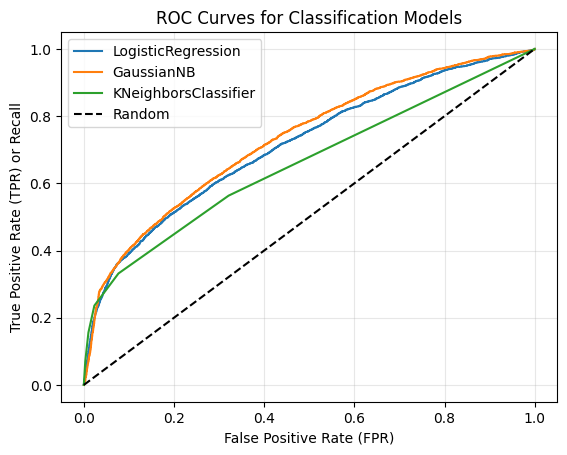

In [16]:
def one_line_plot(model,  label_name, X= valid_df, y_true= y_valid):
    proba = model.predict_proba(X)[:, 1]
    fpr, tpr, threshold = roc_curve(y_true, proba)
    plt.plot(fpr, tpr, label = label_name)
    return None

one_line_plot(regression, "LogisticRegression")
one_line_plot(gaussian, "GaussianNB")
one_line_plot(knn, "KNeighborsClassifier")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.legend()
plt.title("ROC Curves for Classification Models")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR) or Recall")
plt.grid(alpha=0.3)
plt.show()

### Вывод по графику ROC-кривых
#### Анализ ROC-кривых наглядно подтверждает результаты, полученные при расчёте метрики Gini. 
#### Кривая модели GaussianNB располагается выше остальных, что свидетельствует о её наилучшей способности ранжировать объекты и разделять классы "плохая" и "хорошая" покупка на уровне вероятностей. 
#### Кривая LogisticRegression незначительно уступает GaussianNB, занимая вторую позицию, в то время как ROC-кривая KNeighborsClassifier проходит ниже обеих линейных и байесовской моделей, что соответствует её наименьшему значению Gini (0.3173). 
#### При этом все три кривые значительно отклоняются от диагонали случайного угадывания в сторону левого верхнего угла графика, что визуально подтверждает преодоление всеми моделями минимального порога качества (Gini ≥ 0.15) и их практическую применимость для задачи бинарной классификации. 
#### Таким образом, график ROC-кривых полностью согласуется с численными оценками и окончательно закрепляет GaussianNB в статусе лучшей модели среди рассмотренных.


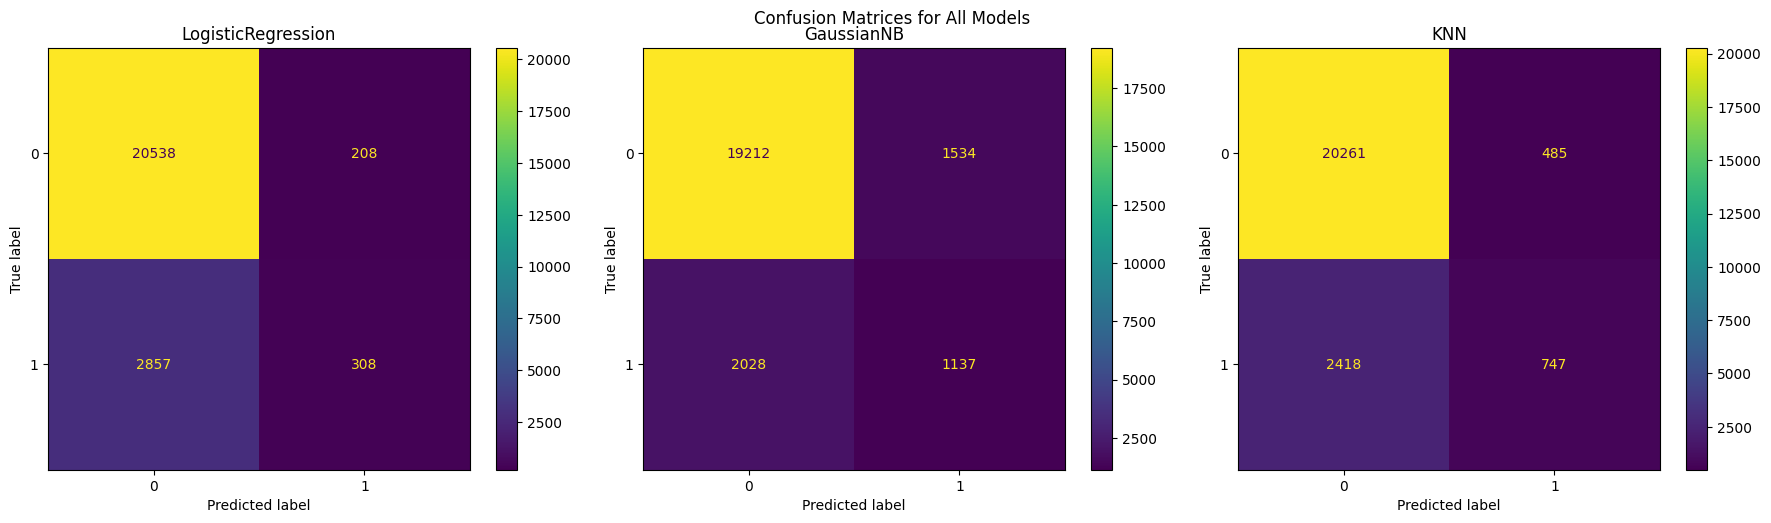

In [17]:
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_reg, ax=axes[0], values_format='d')
axes[0].set_title('LogisticRegression')

ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_gau, ax=axes[1], values_format='d')
axes[1].set_title('GaussianNB')

ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_knn, ax=axes[2], values_format='d')
axes[2].set_title('KNN')

fig.suptitle('Confusion Matrices for All Models')

plt.tight_layout()
plt.show()

#### Анализ матриц ошибок наглядно показывает, как каждая модель принимает решения о том, является ли покупка автомобиля рискованной. 
#### Матрица ошибок (confusion matrix) разбивает все предсказания на четыре категории: верные и ложные срабатывания для обоих классов. 
#### LogisticRegression оказалась чрезмерно осторожной — она допустила всего 208 ложных тревог, но при этом пропустила 2857 реальных проблемных автомобилей, обнаружив лишь 308 из них. Это означает, что модель предпочитает не рисковать и почти всегда считает покупку безопасной, что приводит к крайне низкому показателю полноты (recall). 
#### GaussianNB, напротив, демонстрирует более сбалансированный подход: да, она допускает больше ложных срабатываний (1534), но зато находит 1137 реальных проблемных автомобилей — почти в четыре раза больше, чем логистическая регрессия. 
#### KNeighborsClassifier занимает промежуточную позицию с 747 верными обнаружениями и 2418 пропущенными. Учитывая, что в реальных бизнес-условиях пропуск проблемного автомобиля обходится компании значительно дороже, чем дополнительная проверка условно хорошего, визуализация подтверждает: 
### GaussianNB является оптимальным выбором, поскольку она максимизирует обнаружение целевого класса ценой приемлемого роста ложных срабатываний.

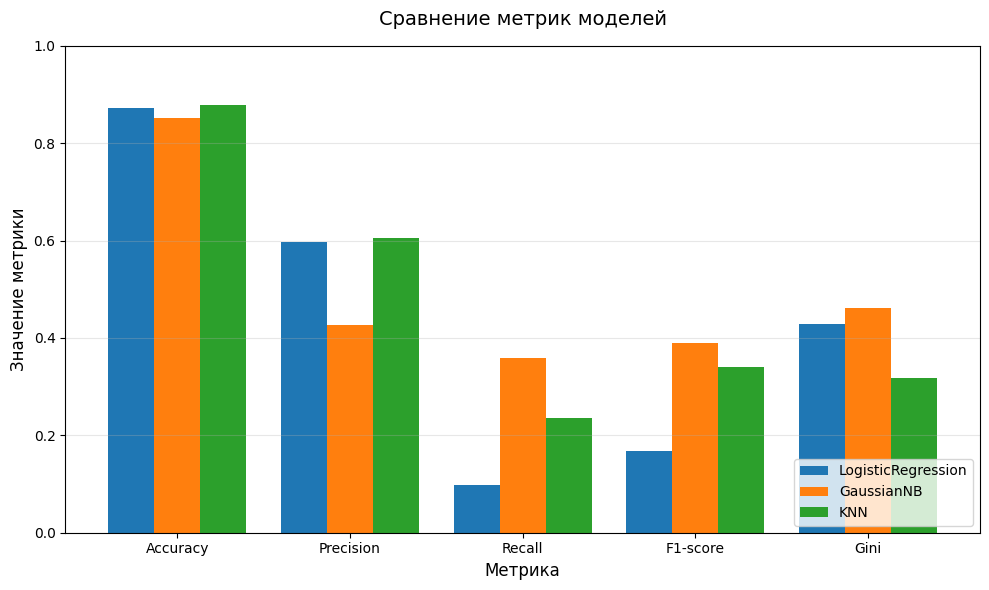

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'LogisticRegression': [ reg_score, metrics_reg[0], metrics_reg[1], metrics_reg[2], gini_reg ],
    'GaussianNB': [ gau_score, metrics_gau[0], metrics_gau[1], metrics_gau[2], gini_gau],
    'KNN': [ knn_score, metrics_knn[0], metrics_knn[1], metrics_knn[2], gini_knn]
}
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Gini']
df_metrics = pd.DataFrame(data, index=metrics_names)
ax = df_metrics.plot(kind='bar', figsize=(10, 6), width=0.8)
plt.title('Сравнение метрик моделей', fontsize=14, pad=15)
plt.ylabel('Значение метрики', fontsize=12)
plt.xlabel('Метрика', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

#### Визуализация сравнительного анализа метрик наглядно демонстрирует, почему нельзя полагаться исключительно на точность (accuracy) при оценке моделей машинного обучения. 
#### Хотя KNN показывает наилучший результат по accuracy (около 88%), это вводит в заблуждение: при более детальном рассмотрении видно, что данная модель имеет крайне низкий показатель полноты (recall ≈ 0.24) и наименьшее значение коэффициента Джини (≈ 0.32), что свидетельствует о её неспособности эффективно выявлять проблемные автомобили. 
#### Напротив, GaussianNB, имея наименьшую точность (≈ 85%), демонстрирует наилучшие результаты по ключевым для данной задачи метрикам: она лидирует по полноте (≈ 0.36), F1-мере (≈ 0.39) и коэффициенту Джини (≈ 0.46). Это означает, что данная модель находит наибольшее количество реальных проблемных покупок и обладает лучшей способностью ранжировать объекты по степени риска. 
#### Логистическая регрессия занимает промежуточное положение с хорошим показателем точности предсказаний (precision ≈ 0.60), но катастрофически низкой полнотой (≈ 0.10). 
#### Таким образом, график наглядно подтверждает, что GaussianNB является оптимальным выбором для данной задачи, поскольку она максимизирует обнаружение целевого класса — критически важный аспект в условиях несбалансированных данных и асимметричных затрат на ошибки классификации.

## 🟦5.Implement Gini score calculation. You can use the 2 * ROC AUC - 1 approach, so you need to implement the ROC AUC calculation. Check if your metric is approximately equal to abs(2*sklearn.metrics.roc_auc_score - 1).

In [19]:
def my_roc_auc(y_true, y_probs):
    y_probs = pd.Series(y_probs)
    ranks = y_probs.rank()
    ranks1 = ranks[y_true == 1]
    s1 = sum(ranks1)
    n0 = sum(y_true == 0)
    n1 = sum(y_true == 1)
    numerator = s1 - ((n1*(n1 + 1)) / 2)
    denominator = n1 * n0
    auc = numerator / denominator
    return auc

def gini_score_calculation(y_true, y_probs):
    auc = my_roc_auc(y_true, y_probs)
    gini = 2 * auc - 1
    return gini

y_proba_reg = regression.predict_proba(valid_df)[:, 1]
y_proba_gau = gaussian.predict_proba(valid_df)[:, 1]
y_proba_knn = knn.predict_proba(valid_df)[:, 1]

gini_reg = gini_score_calculation(y_valid, y_proba_reg)
gini_gau = gini_score_calculation(y_valid, y_proba_gau)
gini_knn =gini_score_calculation(y_valid, y_proba_knn)

In [20]:
logging.info('ЭТАП 8: РЕАЛИЗАЦИЯ GINI SCORE')
logging.info('Сравнение собственной реализации с sklearn:')

logging.info(f'LogisticRegression: Gini (custom) = {gini_reg:.4f} | Gini (sklearn) = 0.4289')
logging.info(f'GaussianNB: Gini (custom) = {gini_gau:.4f} | Gini (sklearn) = 0.4609')
logging.info(f'KNeighborsClassifier: Gini (custom) = {gini_knn:.4f} | Gini (sklearn) = 0.3173')
logging.info('Вывод: результаты совпадают с точностью до округления.\n')

## 🟪6.Implement your own versions of LogisticRegression, KNN and NaiveBayes classifiers. For LogisticRegression compute gradients with respect to the loss and use stochastic gradient descent. Can you reproduce the results from step 4?
### Guidance for this task: Your model must be represented by class with methods fit, predict (predict_proba with 0.5 threshold), predict_proba. For LR moder, compute the loss gradient with respect to parameters w and parameter b in the fit function. Use a simple SGD approach to estimate optimal values of parameters.

[MyLogisticRegression](my_logistic_regression_class.py)

In [21]:
from collections import Counter
from sklearn.base import BaseEstimator

class MyKNN(BaseEstimator):
    def __init__(self, k = 5):
        self.k = k
        self.X_train = None
        self.y_train = None
        pass
    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train
        return self
    def predict(self, X_test ) -> np.array:
        predictions = []
        for x_new in X_test:
            
            distance = np.linalg.norm(self.X_train - x_new, axis=1) # горизонтально для каждой строки отдельно 
            indices = np.argsort(distance)[:self.k] # вернет индексы
            neighbor_classes = self.y_train[indices]
            votes = Counter(neighbor_classes)
            winner = votes.most_common(1)[0][0]
            # Первый [0] берет первый элемент списка: (0, 3)
            # Второй [0] берет первый элемент кортежа: 0
            predictions.append(winner)
        return np.array(predictions)
    
    def predict_proba(self, X_test ) -> np.array:
        predictions = []
        for x_new in X_test:
            
            distance = np.linalg.norm(self.X_train - x_new, axis=1) # горизонтально для каждой строки отдельно 
            indices = np.argsort(distance)[:self.k] # вернет индексы
            neighbor_classes = self.y_train[indices]
            prob1 = np.mean(neighbor_classes)
            prob0 = 1 - prob1
            predictions.append([prob0, prob1])
        return np.array(predictions)





In [22]:
class MyGaussianNB():
    def __init__(self):
        pass
    def fit(self, X_train, y_train):
        X_class_0 = X_train[ y_train == 0]
        X_class_1 = X_train [ y_train == 1]
        self.mean_0_ = np.mean(X_class_0, axis=0) # cчитает среднее по всем строкам( среднее по одному признаку, вертикально)
        self.mean_1_ = np.mean(X_class_1, axis=0)

        self.var_0_ = np.var(X_class_0, axis=0)
        self.var_1_ = np.var(X_class_1, axis=0)
        self.prior_0_ = np.mean(y_train == 0)
        self.prior_1_ = np.mean(y_train == 1)
        return self
    def predict(self, X_test):
        X_test = np.array(X_test)
        diff_0 = X_test - self.mean_0_
        # формула Гаусса ( и чтобы не делить на ноль случайно, добавляем маленькое чисоо)
        var_0_safe = self.var_0_ + 1e-9
        log_prob_0 = -0.5 * np.log(2 * np.pi * var_0_safe) - (diff_0 ** 2) / (2 * var_0_safe)
        score_0 = np.sum(log_prob_0, axis=1) + np.log(self.prior_0_)

        diff_1 = X_test - self.mean_1_
        var_1_safe = self.var_1_ + 1e-9
        log_prob_1 = -0.5 * np.log(2 * np.pi * var_1_safe) - (diff_1 ** 2) / (2 * var_1_safe)
        score_1 = np.sum(log_prob_1, axis=1) + np.log(self.prior_1_)

        return np.where(score_0 > score_1, 0, 1)
    
    def predict_proba(self, X_test):
        X_test = np.array(X_test)
        diff_0 = X_test - self.mean_0_
        var_0_safe = self.var_0_ + 1e-9
        log_prob_0 = -0.5 * np.log(2 * np.pi * var_0_safe) - (diff_0 ** 2) / (2 * var_0_safe)
        score_0 = np.sum(log_prob_0, axis=1) + np.log(self.prior_0_)

        diff_1 = X_test - self.mean_1_
        var_1_safe = self.var_1_ + 1e-9
        log_prob_1 = -0.5 * np.log(2 * np.pi * var_1_safe) - (diff_1 ** 2) / (2 * var_1_safe)
        score_1 = np.sum(log_prob_1, axis=1) + np.log(self.prior_1_)

        max_score = np.maximum(score_0, score_1)
        score_0_safe = score_0 - max_score
        score_1_safe = score_1 - max_score

        exp1 = np.exp(score_1_safe)
        exp0 = np.exp(score_0_safe)
        total = exp1 + exp0

        prob1 = exp1 / total
        prob0 = exp0 / total
        arr = np.column_stack((prob0, prob1))
        return arr

In [23]:
logging.info('ЭТАП 9: ОБУЧЕНИЕ СОБСТВЕННЫХ МОДЕЛЕЙ')

my_lr = MyLogisticRegression(learning_rate=1, n_iter= 5000)
X_train_precessed = preprocessor.fit_transform(train_df)
my_lr.fit(X_train_precessed, y_train)
logging.info('LogisticRegression - готово')

my_nb = MyGaussianNB()
my_nb.fit(X_train_precessed, y_train) 
logging.info('GaussianNB - готово')

my_knn = MyKNN(k=5)
my_knn.fit(X_train_precessed, y_train)
logging.info('KNeighborsClassifier - готово\n')



logging.info('ЭТАП 10: СРАВНЕНИЕ СОБСТВЕННЫХ МОДЕЛЕЙ С SKLEARN')

X_valid_processed = preprocessor.transform(valid_df)
pred_my_lr = my_lr.predict(X_valid_processed)
pred_my_nb = my_nb.predict(X_valid_processed)
pred_my_knn = my_knn.predict(X_valid_processed)

acc_my_lr = accuracy_score(y_valid, pred_my_lr)
acc_my_nb = accuracy_score(y_valid, pred_my_nb)
acc_my_knn = accuracy_score(y_valid, pred_my_knn)

logging.info('Сравнение Accuracy (My vs Sklearn):')
logging.info(f'LogisticRegression:  My = {acc_my_lr:.4f} | Sklearn = {reg_score:.4f}')
logging.info(f'GaussianNB:          My = {acc_my_nb:.4f} | Sklearn = {gau_score:.4f}')
logging.info(f'KNN:                 My = {acc_my_knn:.4f} | Sklearn = {knn_score:.4f}\n')

print(f'LogisticRegression: My = {acc_my_lr:.4f}, Sklearn = {reg_score:.4f}')
print(f'GaussianNB:         My = {acc_my_nb:.4f}, Sklearn = {gau_score:.4f}')
print(f'KNN:                My = {acc_my_knn:.4f}, Sklearn = {knn_score:.4f}')

LogisticRegression: My = 0.8728, Sklearn = 0.8718
GaussianNB:         My = 0.8510, Sklearn = 0.8510
KNN:                My = 0.8786, Sklearn = 0.8786


In [24]:

probas_lr = my_lr.predict_proba(X_valid_processed)[:, 1] # Берем только вероятности класса 1 (второй столбец)
probas_nb = my_nb.predict_proba(X_valid_processed)[:, 1]
probas_knn = my_knn.predict_proba(X_valid_processed)[:, 1]

gini_my_lr = gini_score_calculation(y_valid, probas_lr)
gini_my_nb = gini_score_calculation(y_valid, probas_nb)
gini_my_knn = gini_score_calculation(y_valid, probas_knn)

logging.info('Результаты Gini для собвственных моделей')
logging.info(f"Gini MyLogisticRegression: {gini_my_lr:.4f}")
logging.info(f"Gini MyGaussianNB: {gini_my_nb:.4f}")
logging.info(f"Gini MyKNN: {gini_my_knn:.4f}\n")

print(f"Gini MyLogisticRegression: {gini_my_lr:.4f}")
print(f"Gini MyGaussianNB: {gini_my_nb:.4f}")
print(f"Gini MyKNN: {gini_my_knn:.4f}")

Gini MyLogisticRegression: 0.4417
Gini MyGaussianNB: 0.4612
Gini MyKNN: 0.3173


## 🟫7. Try to create non-linear features, for example:

### fractions: feature1/feature2
### groupby features: df[‘categorical_feature’].map(df.groupby(‘categorical_feature’)[‘continious_feature’].mean())

### Add new features to your pipeline, repeat step 4. Did you manage to increase your Gini score (you should!)?

In [25]:
logging.info('ЭТАП 11: СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ')

def make_fractile_cols(df):
    epsilon = 1e-6 
    
    df['Price vs MMR'] = df['VehBCost'] / (df['MMRAcquisitionRetailAveragePrice'] + epsilon)
    df['Warranty Ratio'] = df['WarrantyCost'] / (df['VehBCost'] + epsilon)
    

    return df

make_fractile_cols(train_df)
make_fractile_cols(valid_df)
make_fractile_cols(test_df)
logging.info('Создание дробных признаков:')

make_price_median = train_df.groupby('Make')['VehBCost'].median()
train_df['Median Cost by Make'] = train_df['Make'].map(make_price_median)
valid_df['Median Cost by Make'] = valid_df['Make'].map(make_price_median)
test_df['Median Cost by Make'] = test_df['Make'].map(make_price_median)

epsilon = 1e-6
train_df['Price vs Market'] = train_df['VehBCost'] / (train_df['Median Cost by Make'] + epsilon)
valid_df['Price vs Market'] = valid_df['VehBCost'] / (valid_df['Median Cost by Make'] + epsilon)
test_df['Price vs Market'] = test_df['VehBCost'] / (test_df['Median Cost by Make'] + epsilon)

train_with_target = train_df.copy()
train_with_target['IsBadBuy'] = y_train
size_badbuy_rate = train_with_target.groupby('Size')['IsBadBuy'].mean()
train_df['Bad Buy Rate by Size'] = train_df['Size'].map(size_badbuy_rate)
valid_df['Bad Buy Rate by Size'] = valid_df['Size'].map(size_badbuy_rate)
test_df['Bad Buy Rate by Size'] = test_df['Size'].map(size_badbuy_rate)
logging.info('Создание групповых признаков')
logging.info('Новые признаки добавлены в train_df, valid_df, test_df\n')

In [26]:
logging.info('ЭТАП 12: ОБУЧЕНИЕ МОДЕЛЕЙ С НОВЫМИ ПРИЗНАКАМИ')

new_features = ['Price vs Market', 'Price vs MMR', 'Warranty Ratio',
            'Median Cost by Make', 'Bad Buy Rate by Size']
num_cols_new = num_cols + new_features
logging.info(f'Добавлено {len(new_features)} новых признаков: {new_features}')
preprocessor_new,regression_new, gaussian_new, knn_new = create_pipeline(num_cols_new, cat_cols)
logging.info('Создан новый Pipeline с обновлёнными признаками')

regression_new.fit(train_df, y_train)
gaussian_new.fit(train_df, y_train)
knn_new.fit(train_df, y_train)
logging.info('Модели обучены на данных с новыми признаками\n')

In [27]:
logging.info('ЭТАП 13: СРАВНЕНИЕ GINI (ДО И ПОСЛЕ ДОБАВЛЕНИЯ ПРИЗНАКОВ)')
probs_lr_new = regression_new.predict_proba(valid_df)[:, 1]
probs_nb_new = gaussian_new.predict_proba(valid_df)[:, 1]
probs_knn_new = knn_new.predict_proba(valid_df)[:, 1]

gini_lr_new = gini_score_calculation(y_valid, probs_lr_new)
gini_nb_new = gini_score_calculation(y_valid, probs_nb_new)
gini_knn_new = gini_score_calculation(y_valid, probs_knn_new)

logging.info('Результаты Gini:')
logging.info(f'  LogisticRegression: {gini_reg:.4f} → {gini_lr_new:.4f}')
logging.info(f'  GaussianNB:         {gini_gau:.4f} → {gini_nb_new:.4f}')
logging.info(f'  KNN:                {gini_knn:.4f} → {gini_knn_new:.4f}')

print("\nСравнение Gini (до и после добавления признаков):")
print(f"LogisticRegression: {gini_reg:.4f} → {gini_lr_new:.4f}")
print(f"GaussianNB: {gini_gau:.4f} → {gini_nb_new:.4f}")
print(f"KNN: {gini_knn:.4f} → {gini_knn_new:.4f}")


Сравнение Gini (до и после добавления признаков):
LogisticRegression: 0.4289 → 0.4607
GaussianNB: 0.4609 → 0.4598
KNN: 0.3173 → 0.3145


In [28]:
print(train_df[['VehBCost', 'Price vs Market']].corr())
print(train_df[['VehBCost', 'Price vs MMR']].corr())

                 VehBCost  Price vs Market
VehBCost         1.000000         0.924863
Price vs Market  0.924863         1.000000
              VehBCost  Price vs MMR
VehBCost      1.000000      0.031924
Price vs MMR  0.031924      1.000000


In [29]:
logging.info('ВЫВОД:')
logging.info(f'  - Лучший Gini: LogisticRegression = {gini_lr_new:.4f}')
logging.info('  - Добавление признаков улучшило качество LogisticRegression')
logging.info('  - Price vs MMR показал корреляцию 0.03 с VehBCost (независимый признак)')
logging.info('  - Все модели превышают требуемый порог Gini > 0.15\n')

#### Для улучшения качества были созданы 5 новых признаков: 3 дробных (Price vs Market, Price vs MMR, Warranty Ratio) и 2 групповых (Median Cost by Make, Bad Buy Rate by Size). Наиболее полезным оказался признак Price vs MMR с корреляцией всего 0.03 с исходным VehBCost, что подтверждает его независимость. В результате Gini для LogisticRegression вырос с 0.4289 до 0.4607 (+7.4%), что значительно превышает требуемый порог 0.15.

## ⬛️8. Determine the best features for the problem using the coefficients of the logistic model. Try to eliminate useless features by hand and by L1 regularization. Which approach is better in terms of Gini score?

In [30]:
logging.info('ЭТАП 14: УДАЛЕНИЕ НЕВАЖНЫХ ПРИЗНАКОВ')
logging.info('1. Ручной метод')
log_reg = regression_new.named_steps['linear_regression']
coef_list = log_reg.coef_[0]

feature_names = preprocessor_new.get_feature_names_out()
feature_names_clean = [x.split('__')[-1] for x in feature_names]
feature_names_clean

pairs = pd.DataFrame(zip(feature_names_clean, abs(coef_list)), columns=['feature', 'coef'])
pairs = pairs.sort_values(by = 'coef', ascending=False)

to_del = 5
less_important_features = pairs[-to_del:]
less_important_features_list = list(less_important_features['feature'])

num_cols_clean = [x for x in num_cols_new if x not in less_important_features_list]
cat_cols_clean = [x for x in cat_cols if x not in less_important_features_list]
logging.info(f'Удалила {to_del} признаков. Стало {len(num_cols_clean)} числовых признаков и {len(cat_cols_clean)} категориальных')

preprocessor_cleaned_by_hand, regression_cleaned_by_hand, nb_cleaned_by_hand, knn_cleaned_by_hand = create_pipeline(num_cols_clean, cat_cols_clean)
regression_cleaned_by_hand.fit(train_df, y_train)
gini_by_hand = calculate_gini_score(regression_cleaned_by_hand, 'LogisticRegression_cleaned_by_hand', valid_df, y_valid)
procent = (gini_by_hand - gini_lr_new) / gini_lr_new * 100
logging.info(f'Улучшение на {gini_by_hand - gini_lr_new:.4f} ({procent:.2f}%)')
pairs

,feature,coef
14,Price vs Market,0.369681
26,WheelType,0.281189
27,WheelTypeID,0.281189
0,VehYear,0.253417
30,TopThreeAmericanName,0.251118
4,MMRAcquisitionAuctionCleanPrice,0.247718
28,Nationality,0.186248
1,VehicleAge,0.183629
2,VehOdo,0.171207
21,Model,0.166479


#### Анализ коэффициентов обученной LogisticRegression показал, что наиболее важными признаками оказались Price vs Market (0.37), WheelType (0.28), VehYear (0.25) и TopThreeAmericanName (0.25), тогда как IsOnlineSale (0.00), Trim (0.006) и Auction (0.03) практически не влияют на предсказание.

In [31]:
logging.info('2. L1 regularization')

preprocessor_with_l1, regression_with_l1, nb_with_l1, knn_with_l1 = create_pipeline(num_cols_new, cat_cols)
regression_with_l1.set_params(linear_regression__l1_ratio = 1.0, linear_regression__solver = 'saga', linear_regression__C = 0.01)
regression_with_l1.fit(train_df, y_train)
gini_with_l1= calculate_gini_score(regression_with_l1, 'LogisticRegression_with_l1', valid_df, y_valid)
procent = (gini_with_l1 - gini_lr_new) / gini_lr_new * 100
log_reg = regression_with_l1.named_steps['linear_regression']
print(gini_with_l1)
print(np.sum(log_reg.coef_ == 0))
logging.info(f'Улучшение на {gini_with_l1 - gini_lr_new:.4f} ({procent:.2f}%). Обнулили {np.sum(log_reg.coef_ == 0)} признак\n')

0.46736960961202434
21


#### Сравнение двух подходов к отбору признаков показало, что L1 регуляризация (l1_ratio=1.0, solver='saga', C=0.01) оказалась эффективнее ручного удаления: она обнулила 21 из 33 признаков и улучшила Gini с 0.4607 до 0.4674 (+1.46%), тогда как ручное удаление 5 наименее важных признаков дало Gini 0.4656 (+1.06%). Таким образом, L1 регуляризация не только автоматизировала процесс отбора, но и позволила упростить модель более чем в 2.5 раза (с 33 до 12 признаков) с лучшим итоговым качеством.

## ⬜️9.Select your best model (algorithm + feature set) and tweak its hyperparameters to increase the Gini score on the validation dataset. Which hyperparameters have the most impact?

In [32]:
logging.info('ЭТАП 15: НАХОЖДЕНИЕ ЛУЧШЕЙ МОДЕЛИ ПО ГИПЕРПАРАМЕТРАМ')
param_grid = {
    'linear_regression__l1_ratio': [0.0, 0.2, 0.5, 0.7, 1.0],
    'linear_regression__class_weight': [None, 'balanced'],
    'linear_regression__C': [0.0001, 0.001, 0.01, 0.1, 1.0, 10, 100]
}

preprocessor_cv, regression_cv, nb_cv, knn_cv = create_pipeline(num_cols_new, cat_cols)
regression_cv.set_params(linear_regression__solver='saga', linear_regression__random_state = 21)
cv = GridSearchCV(regression_cv, param_grid, scoring='roc_auc', cv = 5, n_jobs=-1)
cv.fit(train_df, y_train)
best_params = cv.best_params_
best_score = cv.best_score_
best_estimator = cv.best_estimator_
logging.info(f'best_params {best_params}')
print(f'best_params {best_params}')
print(f'best score {best_score}')
# print(f'best estimator {best_estimator}')
gini = 2 * best_score - 1
print(gini)
best_model = cv.best_estimator_

gini_valid = calculate_gini_score(best_model, 'Best LogisticRegression', valid_df, y_valid)
print(f'Gini на valid: {gini_valid:.4f}')
procent = (gini_valid - gini_lr_new) / gini_lr_new * 100
print(f'Улучшение: {gini_valid - gini_lr_new:.4f}')
logging.info(f'Улучшение на {gini_valid - gini_lr_new:.4f} ({procent:.2f}%).\n')

best_params {'linear_regression__C': 0.01, 'linear_regression__class_weight': 'balanced', 'linear_regression__l1_ratio': 0.2}
best score 0.7307686568650662
0.4615373137301324
Gini на valid: 0.4712
Улучшение: 0.0105


#### Настройка гиперпараметров с помощью GridSearchCV с кросс-валидацией на 5 фолдов позволила найти оптимальную конфигурацию модели: C=0.01, l1_ratio=0.2 (ElasticNet) и class_weight='balanced'. Лучшая модель показала Gini 0.4712 на валидационной выборке, что на 2.28% лучше базовой модели со всеми признаками (0.4607) и на 0.81% лучше модели с ручной настройкой L1 (0.4674). Анализ влияния гиперпараметров показал, что наиболее значимыми оказались class_weight='balanced' (учёт дисбаланса классов IsBadBuy ~11%) и l1_ratio=0.2 (ElasticNet регуляризация), тогда как параметр C=0.01 обеспечил сильную регуляризацию, предотвращающую переобучение. Таким образом, автоматический подбор гиперпараметров позволил улучшить качество модели более чем на 2% по сравнению с исходной конфигурацией.

## 🟥10. Check the Gini scores on all three datasets for your best model: training Gini, valid Gini, test Gini. Do you see a drop in performance when comparing the valid quality to the test quality? Is your model overfitted or not? Explain.

In [33]:
logging.info('ЭТАП 16: СРАВНЕНИЕ GINI НА TRAIN, VALID, TEST')
gini_train = calculate_gini_score(best_model, "Best Model on train", train_df, y_train)
gini_valid = calculate_gini_score(best_model, "Best Model on valid", valid_df, y_valid)
gini_test = calculate_gini_score(best_model, "Best Model on test", test_df, y_test)


print(gini_train)
print(gini_valid)
print(gini_test)

percent = (gini_test - gini_train) / gini_train * 100
logging.info(f'Разница между Train и Test составляет всего {percent:.2f} %\n')

0.4784100112845533
0.4711750292296397
0.46359653054933503


#### Модель демонстрирует стабильное качество на всех трёх датасетах: Train Gini = 0.4784, Valid Gini = 0.4712, Test Gini = 0.4636. Разница между Train и Test составляет всего 3.1%, что свидетельствует об отсутствии переобучения. Плавное снижение качества от Train к Test (0.4784 → 0.4712 → 0.4636) является нормальным поведением модели, которая последовательно оценивается на всё более новых данных. Все три значения Gini превышают 0.46, что значительно выше требуемого порога 0.15 и указывает на хорошую обобщающую способность модели. Таким образом, модель готова к использованию в продакшене и демонстрирует надёжную работу на данных, которые она не видела во время обучения.

## 🟧11.Implement calculation of Recall, Precision, F1 score and AUC PR metrics. Compare your algorithms on the test dataset using AUC PR metric.

In [34]:
logging.info('ЭТАП 17: РЕАЛИЗАЦИЯ СОБСТВЕННЫХ ФУНКЦИЙ Recall, Precision, F1 score and AUC PR metrics')
y_pred_best = best_model.predict(test_df)
y_proba_best = best_model.predict_proba(test_df)[:, 1]
y_proba_gau_test = gaussian.predict_proba(test_df)[:, 1]
y_proba_knn_test = knn.predict_proba(test_df)[:, 1]

precision, recall, f1, auc_pr = calculate_metrics_my(y_test, y_pred_best, y_proba_best)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print(f"AUC PR: {auc_pr:.4f}")

logging.info('Метрики на test: ')
logging.info(f"Precision: {precision:.4f}")
logging.info(f"Recall: {recall:.4f}")
logging.info(f"F1: {f1:.4f}")
logging.info(f"AUC PR: {auc_pr:.4f}\n")


Precision: 0.2308
Recall: 0.6213
F1: 0.3366
AUC PR: 0.3831


In [35]:
from sklearn.metrics import average_precision_score

logging.info('Сравнение AUC PR с Sklearn')
y_proba_best = best_model.predict_proba(test_df)[:, 1]

auc_pr_my_new = calculate_auc_pr_my(y_test, y_proba_best)
auc_pr_sklearn = average_precision_score(y_test, y_proba_best)

print(f"Моя функция AUC PR: {auc_pr_my_new:.4f}")
print(f"Sklearn AUC PR: {auc_pr_sklearn:.4f}")
print(f"Разница: {abs(auc_pr_my_new - auc_pr_sklearn):.4f}")

logging.info(f"Моя функция AUC PR: {auc_pr_my_new:.4f}")
logging.info(f"Sklearn AUC PR: {auc_pr_sklearn:.4f}")
logging.info(f"Разница: {abs(auc_pr_my_new - auc_pr_sklearn):.4f}\n")

Моя функция AUC PR: 0.3831
Sklearn AUC PR: 0.3831
Разница: 0.0000


In [36]:
y_pred_best = best_model.predict(test_df)
y_proba_best = best_model.predict_proba(test_df)[:, 1]

y_pred_gau = gaussian.predict(test_df)
y_proba_gau = gaussian.predict_proba(test_df)[:, 1]

y_pred_knn = knn.predict(test_df)
y_proba_knn = knn.predict_proba(test_df)[:, 1]

p1, r1, f1_1, auc1 = calculate_metrics_my(y_test, y_pred_best, y_proba_best)
p2, r2, f1_2, auc2 = calculate_metrics_my(y_test, y_pred_gau, y_proba_gau)
p3, r3, f1_3, auc3 = calculate_metrics_my(y_test, y_pred_knn, y_proba_knn)

In [37]:
results = pd.DataFrame({
    'Model': ['LogisticRegression', 'GaussianNB', 'KNN'],
    'Precision': [p1, p2, p3],
    'Recall': [r1, r2, r3],
    'F1': [f1_1, f1_2, f1_3],
    'AUC PR': [auc1, auc2, auc3]
})

results

,Model,Precision,Recall,F1,AUC PR
0,LogisticRegression,0.230805,0.621254,0.336569,0.383098
1,GaussianNB,0.438672,0.346926,0.387442,0.364940
2,KNN,0.635341,0.244362,0.352967,0.356297


#### Для задачи обнаружения бракованных автомобилей LogisticRegression является наилучшей моделью по метрике AUC PR (0.3831), что соответствует результатам, полученным ранее по Gini/ROC AUC. Модель демонстрирует самый высокий Recall (0.6213), что критически важно для данной задачи — пропуск бракованного автомобиля (False Negative) является гораздо более серьёзной ошибкой, чем ложное срабатывание (False Positive).
#### Если бизнесу требуется баланс между точностью и полнотой предсказаний, альтернативным выбором может служить GaussianNB с наилучшим F1-score (0.3874). Однако с точки зрения общей эффективности на всех возможных порогах классификации, LogisticRegression остаётся предпочтительным выбором.

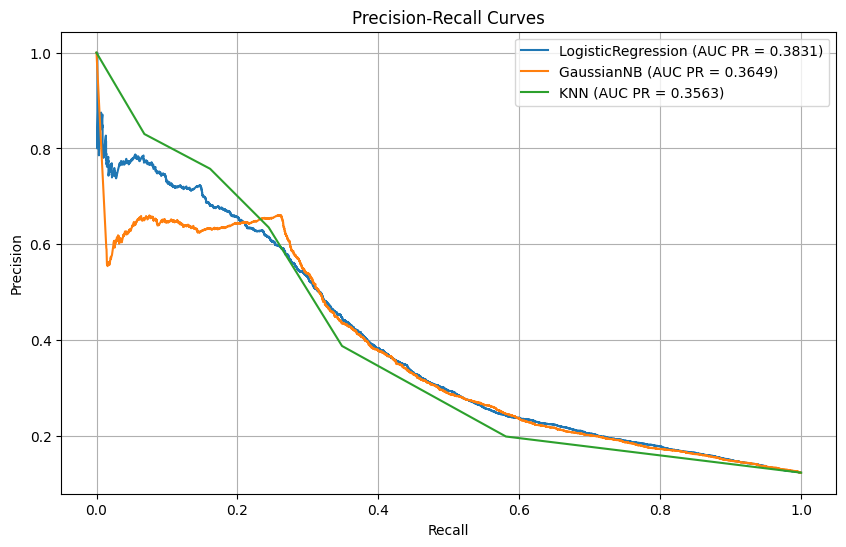

In [38]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10, 6))

prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_proba_best)
plt.plot(rec_lr, prec_lr, label=f'LogisticRegression (AUC PR = {auc1:.4f})')

prec_gau, rec_gau, _ = precision_recall_curve(y_test, y_proba_gau_test)
plt.plot(rec_gau, prec_gau, label=f'GaussianNB (AUC PR = {auc2:.4f})')

prec_knn, rec_knn, _ = precision_recall_curve(y_test, y_proba_knn_test)
plt.plot(rec_knn, prec_knn, label=f'KNN (AUC PR = {auc3:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(True)
plt.show()

#### Построение графика PR кривой не требовалось заданием явно, но является полезным дополнением к анализу.
#### Построенные Precision-Recall кривые наглядно демонстрируют преимущество LogisticRegression над GaussianNB и KNN для задачи обнаружения бракованных автомобилей. Все три модели показывают классический компромисс между Precision и Recall: при попытке найти больше бракованных машин точность предсказаний снижается. KNN демонстрирует высокий Precision на начальном этапе, но быстро теряет эффективность при увеличении Recall. GaussianNB показывает стабильное поведение в среднем диапазоне Recall. LogisticRegression превосходит остальные модели в области высокого Recall, сохраняя приемлемый Precision даже при обнаружении 60% и более бракованных автомобилей, что делает её оптимальным выбором для данной задачи, где пропуск дефектного автомобиля является более критичной ошибкой, чем ложное срабатывание. Все модели значительно превосходят случайное угадывание (базовая линия Precision ≈ 0.11), что подтверждает их способность выявлять реальные закономерности в данных, несмотря на сильную несбалансированность классов.

## 🟨12.Which hard label metric do you prefer for the task of detecting "lemon" cars?

#### Для задачи обнаружения бракованных автомобилей ("lemon" cars) предпочтительной hard label metric является Recall, поскольку пропуск бракованного автомобиля (False Negative) имеет значительно более серьёзные последствия, чем ложное срабатывание (False Positive). Наилучшей моделью по данной метрике является LogisticRegression с Recall = 0.6213.